# This is a Study of Stochastic Volatility

---

Henson Model or Stochastic Volatility model assums that there is mean reversion. Extract the mean reversion rate and volatility of stock and volatility itself.

In [7]:
import sys
sys.path.append('../')
from stockhealth.analyzer import TimeSeries as Ts
from stockhealth.simulation import MonteCarloWithTraining as Mcs
from stockhealth.training import Trends
from stockhealth.model import _NUMBER_OF_TRADING_DAYS_PER_YEAR as Ntd

import seaborn as sns

In [3]:
goog = Ts('GOOG')
goog_training = Trends(stock=goog, number_of_days=30,)
goog_sim = Mcs(trained_model=goog_training, number_of_days=30,)

In [4]:
goog_sim.solve()

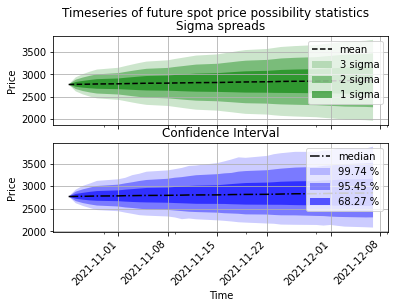

In [5]:
f, a = goog_sim.plot()

In [6]:
goog_training.history

{'mew': 0.280320635094385, 'std': 0.3032873010838303, 'latest close': 2772.5}

In [8]:
df = goog.history__
number_of_days = 30
y = - (
                (df['Risk free return']) * Ntd * 100
        ).rolling(window=number_of_days).mean().diff(periods=-number_of_days)
x = (
        (
            df['Risk free return'] - df['Risk free return'].mean()
        ) * Ntd * 100
).rolling(window=number_of_days).mean()

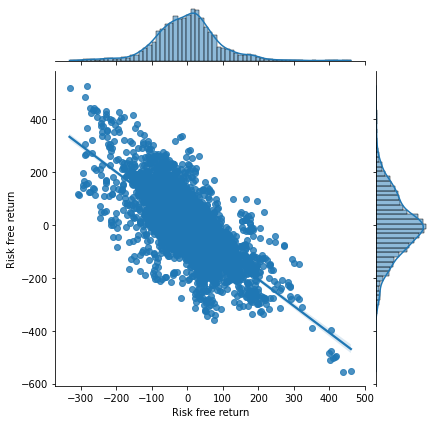

In [17]:
#sns.regplot(x=x, y=y)
#sns.regression.regplot(x=x, y=y)
sns.jointplot(x=x, y=y, kind='reg')